# BAN 8101 Predictive Analytics
## Week 6: Tree-Based Learning for Steering Behavior

### Big Question
**Can a road image help us predict whether a vehicle should turn left, go straight, or turn right?**

This notebook uses the Udacity behavioral-cloning dataset stored on your local computer.

We will use the center-camera image and steering angle to create:

$$
\text{Camera Image} \rightarrow \{\text{Left, Straight, Right}\}
$$

### Learning Objectives
After completing this notebook, you should be able to:

- Explain how a decision tree classifies an image
- Explain how tree depth affects underfitting and overfitting
- Build and evaluate a Decision Tree classifier
- Explain how Random Forest combines many trees
- Explain how Gradient Boosting improves sequentially
- Compare tree-based models with the same cross-validation folds
- Interpret accuracy, macro F1, confusion matrices, and feature importance
- Inspect misclassified driving scenes
- Explain why CNNs are better suited to raw image structure

## This Week's Format: Asynchronous Self-Study

There is no lecture recording this week. This notebook is your guided lesson: the explanations introduce each idea, the code provides an example, and the questions help you check your reasoning.

**Estimated completion time: 90–120 minutes**, including reading, running cells, interpreting outputs, and the completion activity. Model fitting may take longer on some computers.

### What We Will Study

We will use road images and recorded steering actions to study Decision Trees, Random Forest, and Gradient Boosting. We will connect Gini impurity and split selection to the code, examine tree depth and overfitting, and compare models using cross-validation and macro F1. We will then interpret feature importance, confusion matrices, and model failures before considering why CNNs are suited to image structure.

### How to Use This Notebook

1. Read each Markdown section **before** running the cells below it. Work from top to bottom rather than running all cells at once.
2. Set `DATA_DIR` to your local Udacity dataset folder. Confirm that the CSV and image files are available before proceeding.
3. Run one code cell at a time. A cell may use variables created earlier, so return to the preceding cells if you restart the notebook.
4. Pause after tables and figures. Explain what the output means before continuing; producing a plot is only part of the task.
5. Use the **What to Notice**, **Pause and Think**, and **Check Your Understanding** prompts as study checkpoints. Keep brief notes in your own words.
6. Answer the five required completion questions at the end using evidence from your results. The earlier reflection questions are additional study prompts.

You do not need to memorize Python syntax. Focus on what information enters each step, what the step does, and how its output supports a modeling decision. Comments beginning with `#` explain the code and are not executed.

If a cell reports an error, check the dataset path and whether earlier cells ran successfully. Read the final line of the error message before rerunning the cell. If a model is still running, wait for it to finish before starting the next cell.


# Dataset Introduction and Problem Statement

## Dataset Background

This notebook uses the **Udacity behavioral-cloning driving dataset**. During data collection, a vehicle was driven in a simulator while several variables were recorded at the same time.

Each record may contain:

- a center-camera image
- a left-camera image
- a right-camera image
- steering angle
- throttle
- brake
- vehicle speed

For Week 6, we deliberately simplify the problem and use only:

- the **center-camera image**
- the **recorded steering angle**

The center-camera image represents what the vehicle sees directly ahead. The steering angle represents the driver's steering action at that moment.

Conceptually:

$$
\text{Road Image} \longrightarrow \text{Steering Angle}
$$

Later in the semester, we will return to this same relationship using neural networks and CNNs.

For Week 6, however, our objective is different:

> **We will use a self-driving problem to learn how tree-based models work.**

---

## Predictive Problem

We will convert the original continuous steering angle into three classes:

$$
y \in \{\text{Left},\text{Straight},\text{Right}\}
$$

Our question becomes:

> **Can a tree-based model use the current road image to predict whether the vehicle should turn left, continue straight, or turn right?**

This is a **multiclass classification problem**.

The input is an image. After preprocessing, the image will be represented by hundreds of pixel-intensity predictors.

The output is one of three steering categories.

---

## Why This Is Useful for Week 6

Road images contain nonlinear and interacting visual patterns.

For example, the importance of one pixel may depend on the brightness of nearby road pixels, lane markings, shadows, or curves.

Tree-based models are useful because they can represent nonlinear decision rules without requiring us to manually write a linear equation.

This week we will study three related models:

1. **Decision Tree**
2. **Random Forest**
3. **Gradient Boosting**

We will examine both the **mathematics** behind these models and their behavior on a real self-driving dataset.

# 1. Set the Local Dataset Path

Your folder should contain:

```text
data/
├── driving_log.csv
└── IMG/
    ├── center_....jpg
    ├── left_....jpg
    └── right_....jpg
```

Edit `DATA_DIR` below.

Windows example:

```python
DATA_DIR = Path(r"Path to your dataset")
```

Mac/Linux example:

```python
DATA_DIR = Path("Path to your dataset")
```

In [1]:
# Set this folder to the dataset location on your own computer.
# Path joins the folder and filenames in a way that works with local file paths.

from pathlib import Path

DATA_DIR = Path(r"C:\Users\ZXT3080\GitHub\PythonIntroAndDataModeling\data\UdacitySelfDriving")

CSV_PATH = DATA_DIR / "driving_log.csv"
IMG_DIR = DATA_DIR / "IMG"

print("CSV:", CSV_PATH)
print("IMG:", IMG_DIR)

CSV: C:\Users\ZXT3080\GitHub\PythonIntroAndDataModeling\data\UdacitySelfDriving\driving_log.csv
IMG: C:\Users\ZXT3080\GitHub\PythonIntroAndDataModeling\data\UdacitySelfDriving\IMG


# 2. Import Libraries

In [2]:
# These libraries handle tables, images, figures, model fitting, and evaluation.
# A fixed random state makes the random splits repeatable for comparison.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, classification_report

RANDOM_STATE = 42

# Use a subset to keep notebook runtime reasonable.
# Set to None to use all available center-camera records.
MAX_SAMPLES = 3000

print("Libraries loaded.")

Libraries loaded.


# 3. Load `driving_log.csv`

The driving log usually contains:

- center-camera image
- left-camera image
- right-camera image
- steering angle
- throttle
- brake
- speed

For Week 6, we will use only the **center camera** and **steering angle**.

In [3]:
# Read the log into a table using the expected column names.
# The numeric cleanup below also removes a header row if it was read as data.

columns = ["center", "left", "right", "steering", "throttle", "brake", "speed"]

driving = pd.read_csv(
    CSV_PATH,
    names=columns,
    header=None
)

print("Rows:", len(driving))
driving.head()

# Make sure steering is numeric.
# If the CSV contains a header row or any invalid text,
# those values become NaN and are removed.
driving["steering"] = pd.to_numeric(
    driving["steering"],
    errors="coerce"
)

driving = driving.dropna(subset=["steering"]).copy()

print("Rows after steering cleanup:", len(driving))


Rows: 8037
Rows after steering cleanup: 8036


# 4. Repair Image Paths

The CSV may contain image paths from the computer that originally created the dataset.

We only need each filename, because the images are now inside our own local `IMG` folder.

In [4]:
# Keep the image filename and attach it to our local IMG folder.
# Only retain records whose center-camera image is available.

def local_image_path(recorded_path):
    cleaned = str(recorded_path).strip().replace("\\", "/")
    filename = cleaned.split("/")[-1]
    return IMG_DIR / filename

driving["center_path"] = driving["center"].apply(local_image_path)

exists = driving["center_path"].apply(lambda p: Path(p).exists())

print("Images found :", int(exists.sum()))
print("Images missing:", int((~exists).sum()))

driving = driving.loc[exists].copy()

Images found : 8036
Images missing: 0


### What to Notice

Compare the number of images found with the number missing. The remaining rows must point to files on your computer. If no images remain, correct the dataset path before continuing.

# 5. Explore Steering Angles

The original target is continuous.

A steering value near zero means approximately straight driving.

Before turning it into classes, inspect its distribution.

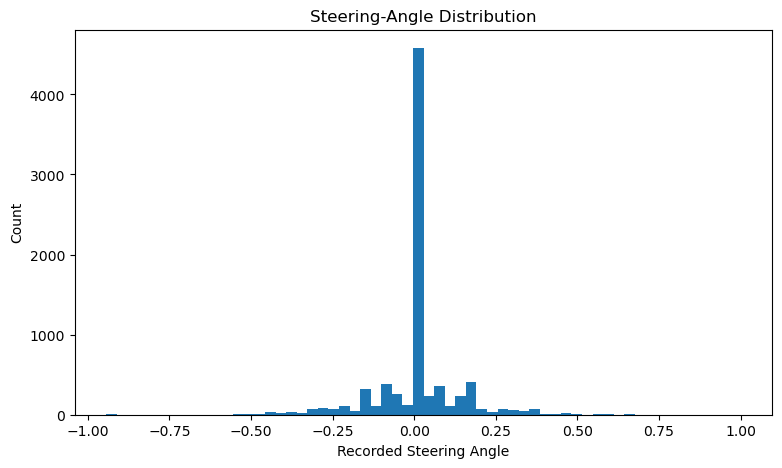

count    8036.000000
mean        0.004070
std         0.128840
min        -0.942695
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: steering, dtype: float64

In [5]:
# Each bar counts observations within a range of steering angles.
# Look for a concentration near zero before interpreting the class balance.

plt.figure(figsize=(9,5))
plt.hist(driving["steering"], bins=60)
plt.xlabel("Recorded Steering Angle")
plt.ylabel("Count")
plt.title("Steering-Angle Distribution")
plt.show()

driving["steering"].describe()

# 6. Convert Steering into Three Classes

For this notebook:

$$
\text{angle} < -0.05 \Rightarrow \text{Left}
$$

$$
-0.05 \leq \text{angle} \leq 0.05 \Rightarrow \text{Straight}
$$

$$
\text{angle} > 0.05 \Rightarrow \text{Right}
$$

The threshold is a teaching choice, not a universal rule.

After checking the class balance, we could choose a different value.

Also visually confirm the sign convention before interpreting negative/positive angles physically.

In [6]:
# Apply the same steering rule to every record to create our target labels.
# The balance table reports both class counts and their shares of the dataset.

STEERING_THRESHOLD = 0.05

def steering_class(angle, threshold=STEERING_THRESHOLD):
    if angle < -threshold:
        return "Left"
    elif angle > threshold:
        return "Right"
    return "Straight"

driving["steering_class"] = driving["steering"].apply(steering_class)

balance = pd.DataFrame({
    "Count": driving["steering_class"].value_counts(),
    "Proportion": driving["steering_class"].value_counts(normalize=True).round(3)
})

balance

,Count,Proportion
steering_class,,
Straight,4881,0.607
Right,1623,0.202
Left,1532,0.191


### Why Macro F1?

If Straight occurs much more often than Left or Right, accuracy may be overly optimistic.

**Macro F1** calculates F1 separately for each class and then averages them equally.

That prevents the largest class from dominating the overall score.

### Pause and Think

Which steering class is most common? If a model always predicted that class, what would its accuracy be? Use the class proportions to estimate it.

### Check Your Understanding

Why should a model with high accuracy still be examined using macro F1? Each class receives equal weight in macro F1, so weak performance on a less frequent turning class still matters.

# 7. Visualize Example Driving Scenes

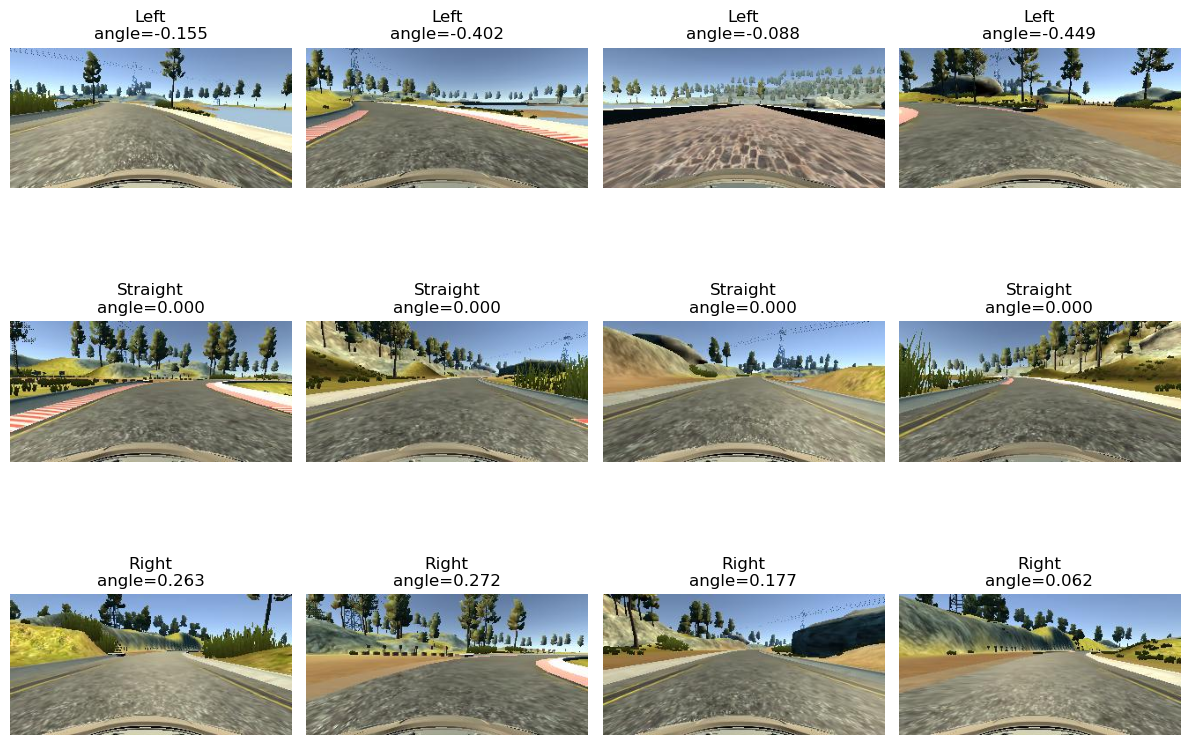

In [7]:
# OpenCV reads colors in BGR order; convert to RGB for correct display.
# Show up to four scenes per class so we can compare the labels with the road views.

def read_rgb(path):
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(3, 4, figsize=(12,9))

for row, label in enumerate(["Left", "Straight", "Right"]):
    subset = driving[driving["steering_class"] == label]
    examples = subset.sample(
        n=min(4, len(subset)),
        random_state=RANDOM_STATE
    )

    for col, (_, rec) in enumerate(examples.iterrows()):
        axes[row, col].imshow(read_rgb(rec["center_path"]))
        axes[row, col].set_title(
            f"{label}\nangle={rec['steering']:.3f}"
        )
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# 8. Image Preprocessing

Original road images are too large for this Week 6 tree demonstration.

We will:

1. crop much of the sky and dashboard
2. convert to grayscale
3. resize to \(32\times16\)
4. flatten the image

This produces:

$$
32\times16=512
$$

pixel predictors.

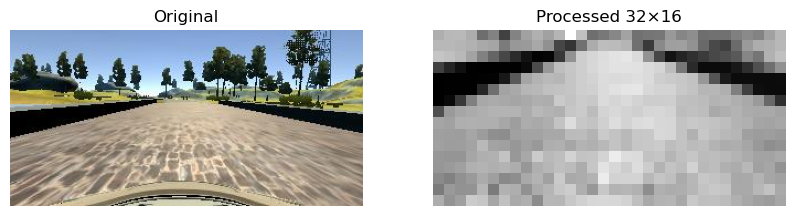

In [8]:
# Apply the same preparation steps to every image for a consistent set of predictors.
# The final division by 255 expresses pixel brightness on a scale from 0 to 1.

RESIZE_WIDTH = 32
RESIZE_HEIGHT = 16

def preprocess_image(path):
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(path)

    h, w = img.shape[:2]

    # Simple road-focused crop for class demonstration
    top = int(h * 0.35)
    bottom = int(h * 0.90)
    cropped = img[top:bottom, :]

    # Remove color so each pixel contributes one brightness value.
    gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)

    # Reduce the image to 32 columns and 16 rows.
    resized = cv2.resize(
        gray,
        (RESIZE_WIDTH, RESIZE_HEIGHT),
        interpolation=cv2.INTER_AREA
    )

    return resized.astype(np.float32) / 255.0

sample_path = driving.iloc[0]["center_path"]

original = read_rgb(sample_path)
processed = preprocess_image(sample_path)

fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(processed, cmap="gray")
axes[1].set_title("Processed 32×16")
axes[1].axis("off")
plt.show()

# 9. Build the Modeling Dataset

In [9]:
# Keep the image path beside its label so we can inspect mistakes later.
# If we take a subset, stratification approximately retains the steering-class proportions.

model_df = driving[["center_path", "steering", "steering_class"]].copy()

if MAX_SAMPLES is not None and len(model_df) > MAX_SAMPLES:
    model_df, _ = train_test_split(
        model_df,
        train_size=MAX_SAMPLES,
        random_state=RANDOM_STATE,
        stratify=model_df["steering_class"]
    )

feature_list = []
kept_paths = []
kept_labels = []

for _, row in model_df.iterrows():
    processed = preprocess_image(row["center_path"])
    # Flatten changes the small image into one row of 512 values.
    feature_list.append(processed.flatten())
    kept_paths.append(row["center_path"])
    kept_labels.append(row["steering_class"])

# Stack the rows into X; y contains the corresponding class labels.
X = np.vstack(feature_list)
y = np.array(kept_labels)
paths = np.array(kept_paths, dtype=object)

print("X shape:", X.shape)
print("y shape:", y.shape)
pd.Series(y).value_counts()

X shape: (3000, 512)
y shape: (3000,)


Straight    1822
Right        606
Left         572
Name: count, dtype: int64

Each image is now represented as:

$$
x_1,x_2,\ldots,x_{512}
$$

The tree does not see a lane or road curve directly.

It sees 512 numerical pixel values.

### What to Notice

In `X.shape`, the first number is the number of images and the second should be 512. Each row contains one image's pixel values. `y` stores its steering class, while `paths` lets us retrieve the original scene later.

### Pause and Think

Compare the original and processed image. What visual detail was lost when we cropped, removed color, and reduced the image size?

# 10. Train/Test Split

In [10]:
# Split pixel values, labels, and paths together so they stay aligned.
# Reserve the test portion while we compare models on the training portion.

X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X,
    y,
    paths,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(y_train))
print("Testing samples :", len(y_test))

Training samples: 2400
Testing samples : 600


### What to Notice

The split reserves 20% of the images for testing. `stratify=y` approximately preserves the class proportions. Cross-validation below uses the training portion; use those results to make model choices before examining final test performance.

# 11A. Mathematics Behind a Classification Tree

A classification tree repeatedly divides the predictor space into smaller regions.

At each node, the algorithm asks:

> **Which feature and which cutoff produce the cleanest separation of the classes?**

For our road-image problem, a candidate split could be:

```text
pixel_217 <= 0.42?
```

That creates two child regions:

$$
R_L = \{x : x_{217} \leq 0.42\}
$$

and

$$
R_R = \{x : x_{217} > 0.42\}
$$

The tree evaluates many possible features and thresholds and chooses the split that best reduces class impurity.

## Gini Impurity

For a node containing \(K\) classes, let:

$$
p_k
$$

be the proportion of observations belonging to class \(k\).

The **Gini impurity** is:

$$
G = 1 - \sum_{k=1}^{K} p_k^2
$$

For our three steering classes:

$$
G
=
1
-
\left(
p_{\text{Left}}^2
+
p_{\text{Straight}}^2
+
p_{\text{Right}}^2
\right)
$$

### Interpretation

- \(G=0\): the node is perfectly pure
- larger \(G\): the node contains a stronger mixture of classes

For example, if every observation in a node is Straight:

$$
p_{\text{Straight}}=1
$$

then:

$$
G = 1-(1^2+0^2+0^2)=0
$$

In [11]:
# Convert counts to class shares, square those shares, and subtract their sum from one.
# Use the two examples to connect the formula with pure and mixed nodes.

# A small Gini impurity helper for demonstration

def gini_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    proportions = counts / counts.sum()
    return 1 - np.sum(proportions ** 2)

# Example 1: perfectly pure node
pure_counts = [0, 100, 0]

# Example 2: mixed node
mixed_counts = [30, 40, 30]

print("Pure-node Gini :", round(gini_from_counts(pure_counts), 3))
print("Mixed-node Gini:", round(gini_from_counts(mixed_counts), 3))

Pure-node Gini : 0.0
Mixed-node Gini: 0.66


### Check Your Understanding

A node contains 80 Straight, 10 Left, and 10 Right observations. Calculate its Gini impurity before continuing. Would it be more or less mixed than the 30/40/30 example?

<details><summary>Check your reasoning after trying the calculation</summary>

The impurity is $1-(0.8^2+0.1^2+0.1^2)=0.34$. This is below 0.66 because one class dominates. A pure node has impurity zero; lower impurity does not mean the entire model is accurate.

</details>

## How the Tree Chooses a Split

Suppose a parent node contains \(n\) observations.

A proposed split produces:

- \(n_L\) observations in the left child
- \(n_R\) observations in the right child

The weighted impurity after the split is:

$$
G_{\text{split}}
=
\frac{n_L}{n}G_L
+
\frac{n_R}{n}G_R
$$

The impurity reduction is:

$$
\Delta G
=
G_{\text{parent}}
-
G_{\text{split}}
$$

The tree prefers splits with a **larger impurity reduction**.

In plain language:

> A good split creates child nodes that are more class-pure than the parent node.

## Numerical Example of a Candidate Split

Suppose the parent node contains 100 observations:

- Left: 30
- Straight: 40
- Right: 30

Its impurity is:

$$
G_{\text{parent}}
=
1-(0.30^2+0.40^2+0.30^2)
=
0.66
$$

Now imagine a candidate pixel split creates:

### Left child
- Left: 25
- Straight: 20
- Right: 5

### Right child
- Left: 5
- Straight: 20
- Right: 25

We can calculate the weighted impurity and determine whether this split is better than the parent.

In [12]:
# Calculate impurity before and after this candidate split.
# Weight each child by its size, then subtract from the parent to measure the gain.

parent = [30, 40, 30]
left_child = [25, 20, 5]
right_child = [5, 20, 25]

g_parent = gini_from_counts(parent)
g_left = gini_from_counts(left_child)
g_right = gini_from_counts(right_child)

n_parent = sum(parent)
n_left = sum(left_child)
n_right = sum(right_child)

g_split = (
    (n_left / n_parent) * g_left
    + (n_right / n_parent) * g_right
)

gain = g_parent - g_split

print("Parent Gini        :", round(g_parent, 3))
print("Left-child Gini    :", round(g_left, 3))
print("Right-child Gini   :", round(g_right, 3))
print("Weighted split Gini:", round(g_split, 3))
print("Impurity reduction :", round(gain, 3))

Parent Gini        : 0.66
Left-child Gini    : 0.58
Right-child Gini   : 0.58
Weighted split Gini: 0.58
Impurity reduction : 0.08


### What to Notice

The parent impurity is 0.66, each child impurity is 0.58, and the weighted impurity is 0.58. The reduction is therefore 0.08. This split improves purity, but another candidate could improve it more.

### Pause and Think

Why weight each child's impurity by its share of observations? If one child contained 90 observations and the other 10, a simple equal average would give the smaller group too much influence. Also distinguish a **left child node** from the steering class **Left**: the branch name describes the split, not the target class.

## Entropy: Another Possible Split Criterion

Another common impurity measure is **entropy**:

$$
H
=
-
\sum_{k=1}^{K}
p_k\log_2(p_k)
$$

Like Gini impurity:

- entropy is 0 for a perfectly pure node
- entropy increases as classes become more mixed

In scikit-learn, `DecisionTreeClassifier` uses **Gini impurity by default** unless another criterion is specified.

For this course, the key idea is more important than memorizing both formulas:

> **The tree searches for splits that reduce class uncertainty.**

## Recursive Binary Splitting

After choosing the best first split, the tree repeats the same process inside each child node:

```text
Choose best split
        ↓
Create two child nodes
        ↓
Choose best split inside each child
        ↓
Repeat
```

The process stops when a stopping rule is reached, such as:

- maximum tree depth
- too few observations in a node
- a node becomes pure
- additional splits provide too little improvement

This is why parameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf` control tree complexity.

## Why Deep Trees Can Overfit

As a tree becomes deeper, it can create increasingly specific regions of the training data.

A very deep tree may eventually create rules that explain small quirks or noise in the training sample.

This often produces:

$$
\text{Very Low Training Error}
$$

but not necessarily:

$$
\text{Low Validation Error}
$$

In bias-variance language:

### Shallow tree

$$
\text{Higher Bias, Lower Variance}
$$

### Very deep tree

$$
\text{Lower Bias, Higher Variance}
$$

Cross-validation helps us find a depth that balances these competing effects.

## Brief Note: Regression Trees

The same tree idea can also predict a continuous target.

In a regression tree, each terminal region \(R_m\) predicts the average target value of observations in that region:

$$
\hat{y}_{R_m}
=
\frac{1}{N_m}
\sum_{i:x_i\in R_m}y_i
$$

A common split objective is to minimize within-region squared error:

$$
RSS
=
\sum_{m=1}^{M}
\sum_{i:x_i\in R_m}
(y_i-\hat{y}_{R_m})^2
$$

Our Week 6 steering example uses a **classification tree**, but the recursive partitioning idea is the same.

# 11. Decision Tree

A tree classifies by asking repeated questions such as:

```text
Is pixel 217 <= 0.42?
```

### Key Terms

- Root node
- Internal node
- Leaf node
- Split
- Depth

In [13]:
# Begin with a shallow tree so its decision rules are easier to inspect.
# Balanced class weights give more weight to classes with fewer training observations.

tree3 = DecisionTreeClassifier(
    max_depth=3,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

# fit learns rules from examples; predict applies those learned rules.
tree3.fit(X_train, y_train)

train_pred = tree3.predict(X_train)
test_pred = tree3.predict(X_test)

print("Training Accuracy:", round(accuracy_score(y_train, train_pred), 3))
print("Test Accuracy    :", round(accuracy_score(y_test, test_pred), 3))
print("Test Macro F1    :", round(f1_score(y_test, test_pred, average="macro"), 3))

Training Accuracy: 0.574
Test Accuracy    : 0.545
Test Macro F1    : 0.548


# 12. Visualize the Tree

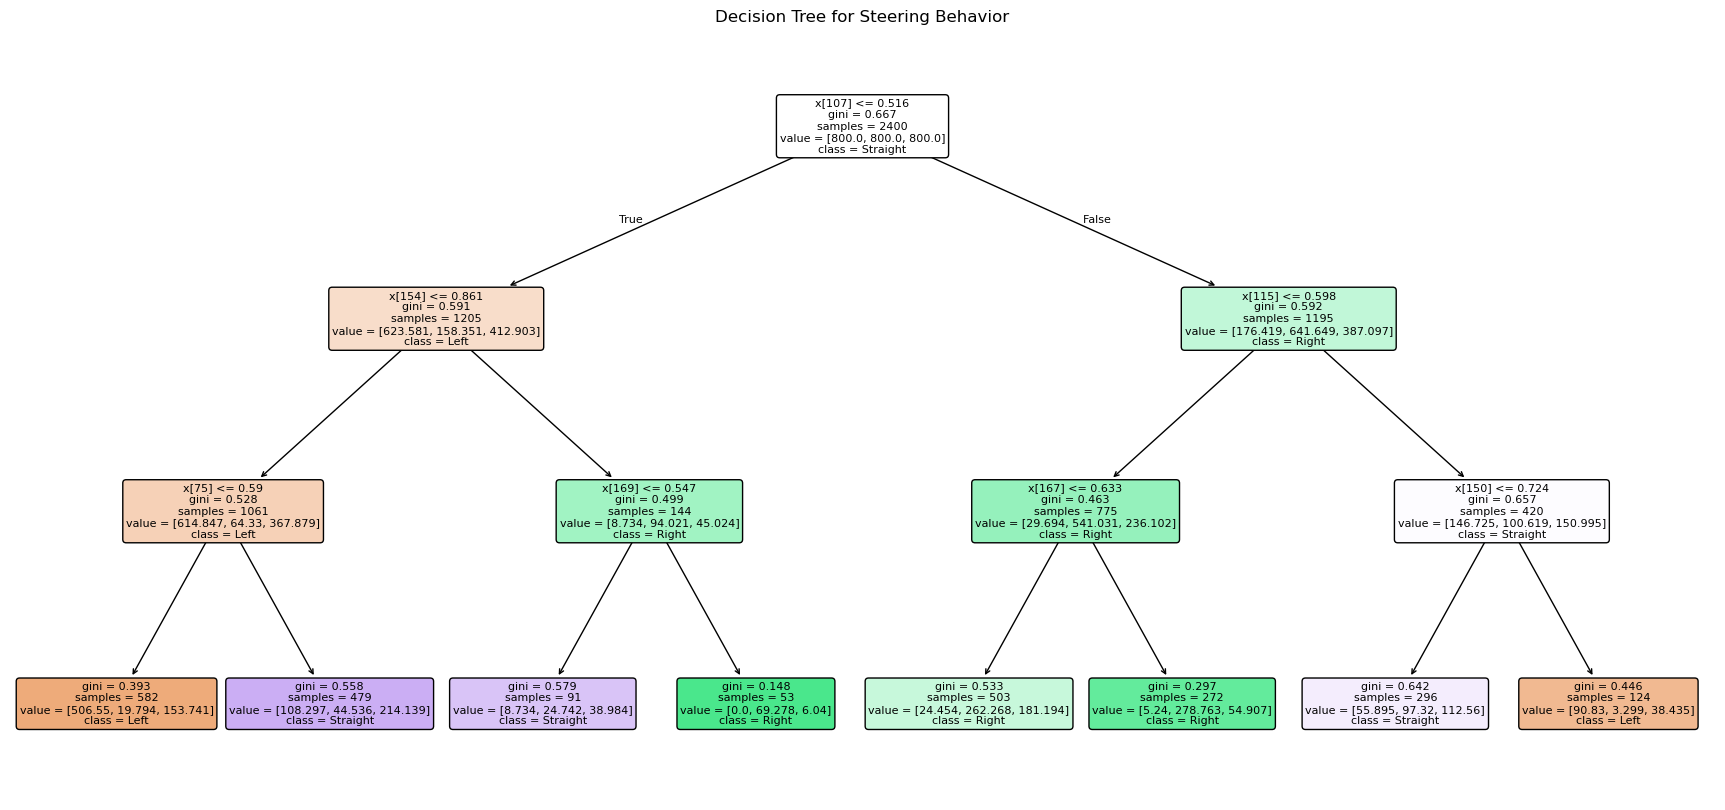

In [14]:
# Display the fitted tree so we can follow the sequence of pixel-based questions.
# The fill colors help distinguish the classes favored at different nodes.

plt.figure(figsize=(22,10))
plot_tree(
    tree3,
    filled=True,
    rounded=True,
    class_names=tree3.classes_,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree for Steering Behavior")
plt.show()

### What to Notice

Read the tree from the root down one branch at a time. Each internal node tests a pixel value; a leaf provides a predicted class. The pixel number identifies a predictor, not a named object such as a lane marking.

# 13. Tree Depth and Overfitting

Increasing depth gives the tree more flexibility.

Training accuracy often keeps increasing.

Cross-validation performance may eventually stop improving.

That gap is evidence of overfitting.

In [15]:
# Use five folds: each fold is held out in turn while the others are used for fitting.
# Try several depth limits and record both training and cross-validation performance.

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

depths = [2, 3, 5, 8, 12, 18, None]
rows = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))

    # These scores come from held-out folds within the training portion.
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={"accuracy":"accuracy", "f1_macro":"f1_macro"}
    )

    rows.append({
        "Max Depth": "None" if depth is None else depth,
        "Training Accuracy": train_acc,
        "Mean CV Accuracy": scores["test_accuracy"].mean(),
        "Mean CV Macro F1": scores["test_f1_macro"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std()
    })

depth_results = pd.DataFrame(rows)
depth_results.round(3)

,Max Depth,Training Accuracy,Mean CV Accuracy,Mean CV Macro F1,CV Accuracy Std
0,2,0.422,0.493,0.484,0.056
1,3,0.574,0.543,0.530,0.056
2,5,0.693,0.589,0.579,0.025
3,8,0.826,0.616,0.595,0.020
4,12,0.935,0.632,0.596,0.016
5,18,0.978,0.637,0.590,0.020
6,None,1.000,0.625,0.571,0.018


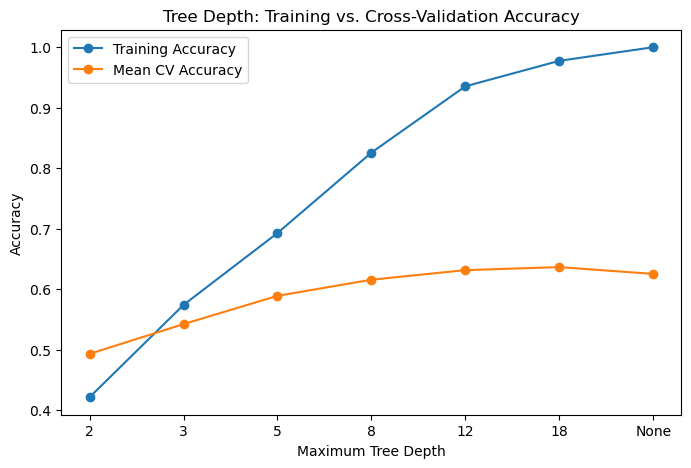

In [16]:
# Place training and validation results on the same figure to compare their patterns.
# A widening gap can reveal a tree that fits its training observations too closely.

plot_df = depth_results.copy()
plot_df["Depth"] = plot_df["Max Depth"].astype(str)

plt.figure(figsize=(8,5))
plt.plot(plot_df["Depth"], plot_df["Training Accuracy"], marker="o", label="Training Accuracy")
plt.plot(plot_df["Depth"], plot_df["Mean CV Accuracy"], marker="o", label="Mean CV Accuracy")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Tree Depth: Training vs. Cross-Validation Accuracy")
plt.legend()
plt.show()

### What to Notice

Compare training accuracy with mean cross-validation accuracy as depth increases. A widening gap, especially when validation performance stops improving, suggests overfitting. Your results may vary; describe the pattern you actually observe.

### Check Your Understanding

Would you choose the deepest tree simply because it has the highest training accuracy? Explain why performance on observations excluded from fitting is more useful for this choice.

# 14. Select the Best Tree Depth

In [17]:
# Find the row with the highest mean cross-validation macro F1.
# Translate the table entry back into the depth setting expected by the model.

best_tree_row = depth_results.loc[
    depth_results["Mean CV Macro F1"].idxmax()
]

best_depth_value = best_tree_row["Max Depth"]
best_depth = None if best_depth_value == "None" else int(best_depth_value)

print("Selected depth:", best_depth)
print("Mean CV Accuracy :", round(best_tree_row["Mean CV Accuracy"], 3))
print("Mean CV Macro F1 :", round(best_tree_row["Mean CV Macro F1"], 3))

Selected depth: 12
Mean CV Accuracy : 0.632
Mean CV Macro F1 : 0.596


### Pause and Think

The code chooses depth using mean cross-validation macro F1. Does that depth also have the highest training accuracy? Explain why the two choices can differ. `None` allows depth to grow without a specified maximum; it does not mean zero depth.

# 15A. Mathematics Behind Random Forest

A single decision tree can have high variance:

> small changes in the training data can produce a noticeably different tree.

Random Forest reduces this instability by averaging or voting across many trees.

Suppose the forest contains \(B\) trees:

$$
T_1(x),T_2(x),\ldots,T_B(x)
$$

For classification, the forest predicts the class receiving the most votes:

$$
\hat{y}
=
\operatorname{mode}
\left\{
T_1(x),
T_2(x),
\ldots,
T_B(x)
\right\}
$$

For regression, the forest averages the tree predictions:

$$
\hat{y}
=
\frac{1}{B}
\sum_{b=1}^{B}T_b(x)
$$

## Bootstrap Sampling

Each tree is trained on a **bootstrap sample** of the training data.

A bootstrap sample is created by sampling observations **with replacement**.

This means:

- some observations may appear multiple times
- some observations may not appear in a particular tree's sample

Therefore, each tree sees a somewhat different training dataset.

This creates diversity among the trees.

## Random Feature Selection

Random Forest introduces a second source of randomness.

At each split, the tree considers only a random subset of the available predictors.

Why?

If every tree always considered all 512 pixels, the strongest pixels might dominate nearly every tree, making the trees highly correlated.

The goal is:

$$
\text{Less Correlated Trees}
\Rightarrow
\text{More Benefit from Averaging}
$$

Averaging many diverse models tends to reduce variance.

## Why Averaging Helps

Imagine several models that each contain some prediction noise.

If their errors are not perfectly correlated, averaging can cancel part of that noise.

This is the key statistical idea behind Random Forest:

> **Keep the strength of decision trees, but reduce the instability of relying on only one tree.**

Random Forest is therefore mainly a **variance-reduction ensemble method**.

### Check Your Understanding

Why would 200 identical trees offer little benefit over one tree? Explain how bootstrap samples and random feature subsets encourage different trees, and why less correlated errors make variance reduction possible. More trees alone do not guarantee better predictions.

# 15. Random Forest

A Random Forest combines many trees.

Each tree sees:

- a bootstrap sample of observations
- random subsets of features

The trees vote on the final class.

This mainly reduces the instability of relying on one tree.

In [18]:
# Build 150 trees; their combined predictions form the forest.
# Reuse the same cross-validation setup for a fairer comparison with the single tree.
# n_jobs=-1 lets the computation use the available processor cores.

rf = RandomForestClassifier(
    n_estimators=150,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_cv = cross_validate(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring={"accuracy":"accuracy", "f1_macro":"f1_macro"},
    n_jobs=-1
)

print("Random Forest Mean CV Accuracy:", round(rf_cv["test_accuracy"].mean(), 3))
print("Random Forest Mean CV Macro F1:", round(rf_cv["test_f1_macro"].mean(), 3))
print("Random Forest CV Accuracy Std :", round(rf_cv["test_accuracy"].std(), 3))

Random Forest Mean CV Accuracy: 0.745
Random Forest Mean CV Macro F1: 0.671
Random Forest CV Accuracy Std : 0.004


### What to Notice

Compare the forest's cross-validation scores with the single tree's scores. The standard deviation describes variation in accuracy across these folds; a smaller value suggests more consistent results in this comparison, but does not guarantee performance on every future dataset.

# 16. Pixel Feature Importance

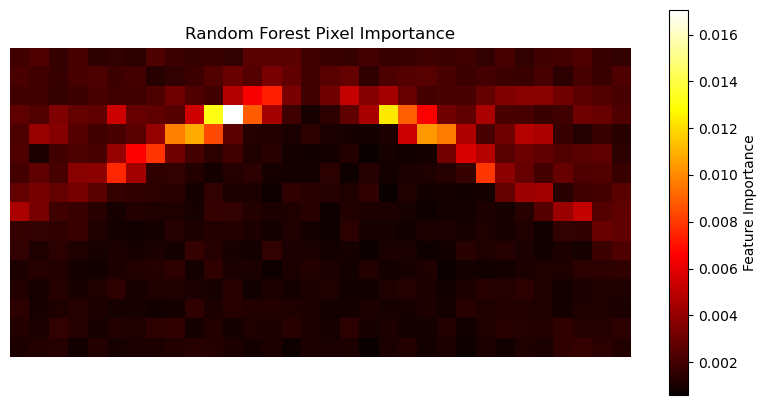

In [19]:
# Fit the forest on the training data before obtaining its pixel importances.
# Restore the 16-by-32 arrangement so each importance appears at its pixel location.

rf.fit(X_train, y_train)

# There is one importance value for each of the 512 pixel predictors.
importance_map = rf.feature_importances_.reshape(
    RESIZE_HEIGHT,
    RESIZE_WIDTH
)

plt.figure(figsize=(10,5))
plt.imshow(importance_map, cmap="hot")
plt.colorbar(label="Feature Importance")
plt.title("Random Forest Pixel Importance")
plt.axis("off")
plt.show()

Feature importance means the model relied on those pixel regions more heavily.

It does **not** imply causation.

### Discussion

- Which road regions appear most useful?
- Do lower road pixels matter more than sky/background?
- Could neighboring correlated pixels make the map harder to interpret?

### Pause and Think

Identify one region with high importance and relate it to the processed image. These values summarize reductions in impurity attributed to pixels in this fitted forest. They do not establish that the region causes steering behavior, and correlated neighboring pixels can share or compete for importance. Describe an apparent pattern without claiming the model understands a road feature.

# 17A. Mathematics Behind Gradient Boosting

Gradient Boosting also combines many trees, but the trees are not built independently.

Instead, the model is constructed **sequentially**.

A boosted model can be written as an additive model:

$$
F_M(x)
=
F_0(x)
+
\eta h_1(x)
+
\eta h_2(x)
+
\cdots
+
\eta h_M(x)
$$

where:

- \(F_0(x)\) is the initial model
- \(h_m(x)\) is the tree added at stage \(m\)
- \(M\) is the number of boosting stages
- \(\eta\) is the learning rate

## Residual-Correction Intuition

For a simple regression problem, suppose the current prediction is:

$$
\hat{y}_i
$$

The residual is:

$$
r_i
=
y_i-\hat{y}_i
$$

The next small tree is trained to predict these residuals.

Then the model updates:

$$
\hat{y}_{\text{new}}
=
\hat{y}_{\text{old}}
+
\eta h(x)
$$

So each new tree acts like a **correction** to the current model.

For classification, the actual mathematics uses gradients of a classification loss rather than ordinary residuals, but the intuition is the same:

> **Each new tree focuses on what the current ensemble is still getting wrong.**

## Learning Rate

The learning rate \(\eta\) controls how strongly each new tree changes the model.

### Small learning rate

$$
\eta \text{ small}
$$

Each tree makes a small correction. Usually more trees are needed.

### Large learning rate

$$
\eta \text{ large}
$$

Each tree makes a larger correction. Learning may be faster, but overfitting can occur more easily.

This creates a trade-off between:

- `learning_rate`
- `n_estimators`
- tree depth

### Check Your Understanding

In the update equation, what happens to the contribution of a new tree when the learning rate is reduced? Smaller steps usually require more stages; a smaller learning rate does not automatically produce a better model when the number of stages is fixed.

## Random Forest vs. Gradient Boosting

### Random Forest

$$
\text{Many Trees Built in Parallel-ish}
\rightarrow
\text{Vote / Average}
$$

Primary goal:

$$
\text{Reduce Variance}
$$

### Gradient Boosting

$$
F_M(x)
=
F_{M-1}(x)+\eta h_M(x)
$$

Primary goal:

$$
\text{Sequentially Reduce Remaining Error}
$$

This distinction is one of the most important conceptual differences between the two ensemble methods.

# 17. Gradient Boosting

Random Forest builds trees mostly independently.

Gradient Boosting builds them sequentially.

Each new tree tries to improve the remaining errors from the current ensemble.

In [20]:
# Fit a sequence of small trees, with each stage contributing a scaled correction.
# Evaluate it on the same training folds used for the other models.

gb = GradientBoostingClassifier(
    n_estimators=60,
    learning_rate=0.08,
    max_depth=2,
    random_state=RANDOM_STATE
)

gb_cv = cross_validate(
    gb,
    X_train,
    y_train,
    cv=cv,
    scoring={"accuracy":"accuracy", "f1_macro":"f1_macro"}
)

print("Gradient Boosting Mean CV Accuracy:", round(gb_cv["test_accuracy"].mean(), 3))
print("Gradient Boosting Mean CV Macro F1:", round(gb_cv["test_f1_macro"].mean(), 3))
print("Gradient Boosting CV Accuracy Std :", round(gb_cv["test_accuracy"].std(), 3))

Gradient Boosting Mean CV Accuracy: 0.723
Gradient Boosting Mean CV Macro F1: 0.641
Gradient Boosting CV Accuracy Std : 0.012


### What to Notice

Here `learning_rate=0.08` scales each correction, `n_estimators=60` sets the number of boosting stages, and `max_depth=2` keeps the individual trees small. Compare the reported scores with Random Forest. Explain the difference between sequential correction and combining diverse trees; do not infer that either method must win.

# 18. Compare the Models

In [21]:
# Evaluate the selected tree depth and collect the three models in one table.
# Sort by mean macro F1 so the first row is the model selected for final evaluation.

best_tree = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

tree_cv = cross_validate(
    best_tree,
    X_train,
    y_train,
    cv=cv,
    scoring={"accuracy":"accuracy", "f1_macro":"f1_macro"}
)

comparison = pd.DataFrame({
    "Model": [
        f"Decision Tree (depth={best_depth})",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean CV Accuracy": [
        tree_cv["test_accuracy"].mean(),
        rf_cv["test_accuracy"].mean(),
        gb_cv["test_accuracy"].mean()
    ],
    "Mean CV Macro F1": [
        tree_cv["test_f1_macro"].mean(),
        rf_cv["test_f1_macro"].mean(),
        gb_cv["test_f1_macro"].mean()
    ],
    "CV Accuracy Std": [
        tree_cv["test_accuracy"].std(),
        rf_cv["test_accuracy"].std(),
        gb_cv["test_accuracy"].std()
    ]
}).sort_values("Mean CV Macro F1", ascending=False)

comparison.round(3)

,Model,Mean CV Accuracy,Mean CV Macro F1,CV Accuracy Std
1,Random Forest,0.745,0.671,0.004
2,Gradient Boosting,0.723,0.641,0.012
0,Decision Tree (depth=12),0.632,0.596,0.016


### Discussion

- Which model has the highest macro F1?
- Which has the highest accuracy?
- Which appears most stable?
- Is the most complex model automatically the best?
- Which model would you choose before looking at the test set?

### Pause and Think

Choose a model from the comparison table and write down your reason before proceeding. Use mean cross-validation macro F1 and consider fold-to-fold variation. Small score differences deserve cautious interpretation; the highest accuracy need not identify the model with the strongest performance across all classes.

# 19. Final Test Evaluation

In [22]:
# Select the model using the cross-validation comparison, then fit it on all training data.
# Predict the reserved test observations and compare predictions with their actual labels.

best_model_name = comparison.iloc[0]["Model"]

if best_model_name.startswith("Decision Tree"):
    final_model = best_tree
elif best_model_name == "Random Forest":
    final_model = rf
else:
    final_model = gb

final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

print("Selected model:", best_model_name)
print("Test Accuracy:", round(accuracy_score(y_test, final_pred), 3))
print("Test Macro F1:", round(f1_score(y_test, final_pred, average="macro"), 3))

Selected model: Random Forest
Test Accuracy: 0.743
Test Macro F1: 0.662


# 20. Confusion Matrix

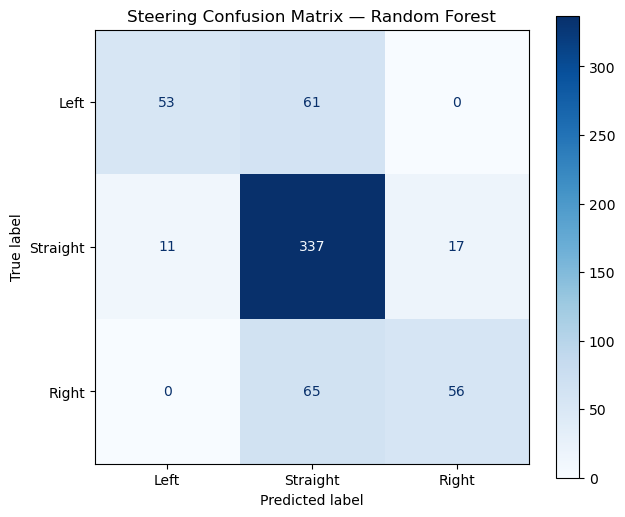

In [23]:
# Compare actual classes with predicted classes in the stated label order.
# Correct predictions appear on the diagonal; other cells show specific mistakes.

fig, ax = plt.subplots(figsize=(7,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    labels=["Left", "Straight", "Right"],
    ax=ax,
    cmap="Blues"
)

plt.title(f"Steering Confusion Matrix — {best_model_name}")
plt.show()

Examples:

- Actual Left → Predicted Straight: the turn was missed
- Actual Straight → Predicted Right: unnecessary steering
- Actual Right → Predicted Left: directionally severe error

The confusion matrix shows **which driving mistakes occur**, not only how many.

### Check Your Understanding

Read one row at a time: rows are actual classes and columns are predicted classes. The diagonal contains correct predictions. Which off-diagonal entry is largest, and what error does it represent?

### Pause and Think

A frequent error and a consequential error may differ. Compare missed turns with predictions of the opposite direction. Explain what the counts reveal about this model, without treating the notebook's scores as evidence that it is ready to control a vehicle.

# 21. Classification Report

In [24]:
# Report performance separately for each class rather than relying on one overall score.

print(classification_report(y_test, final_pred, digits=3))

              precision    recall  f1-score   support

        Left      0.828     0.465     0.596       114
       Right      0.767     0.463     0.577       121
    Straight      0.728     0.923     0.814       365

    accuracy                          0.743       600
   macro avg      0.774     0.617     0.662       600
weighted avg      0.755     0.743     0.725       600



### What to Notice

In the report, precision asks how often a predicted class is correct; recall asks how many actual members of that class were found. `support` is the number of test observations in the class. Compare class-level F1 values with the macro average, and identify whether a strong overall score hides a weak turning class.

# 22. Inspect Misclassified Road Images

Misclassified test images: 154


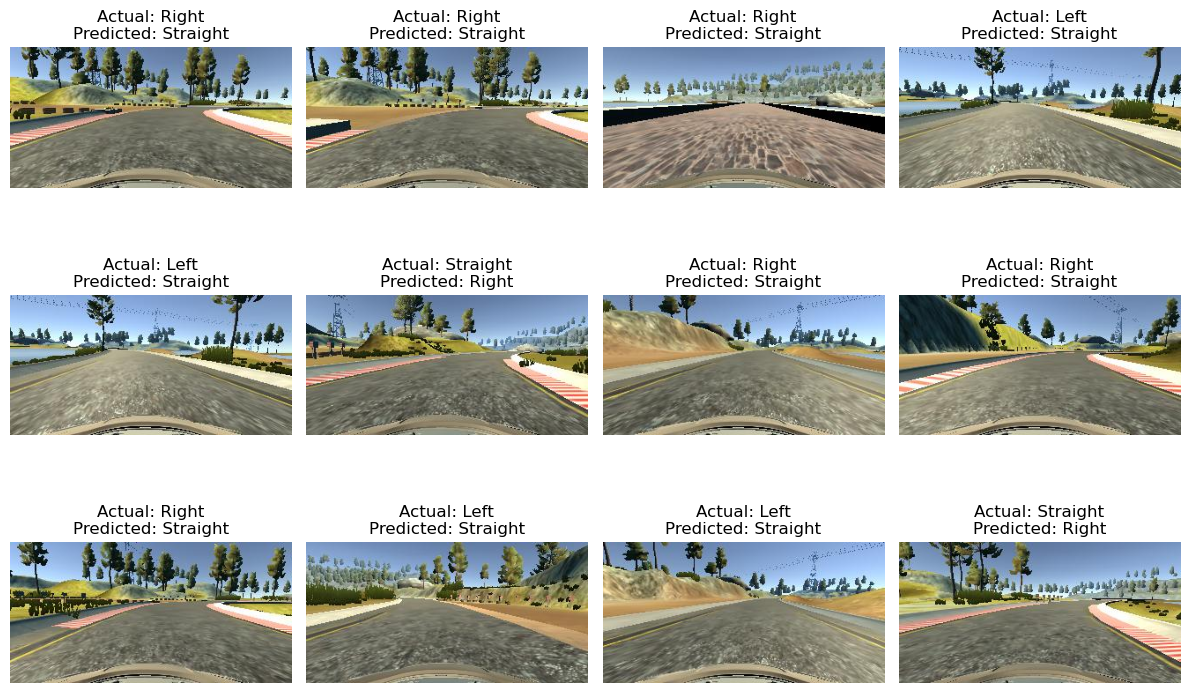

In [25]:
# Find the positions where the predicted and actual classes disagree.
# Use the aligned paths to show the original scenes for up to twelve errors.

wrong_idx = np.where(final_pred != y_test)[0]

print("Misclassified test images:", len(wrong_idx))

n_show = min(12, len(wrong_idx))
fig, axes = plt.subplots(3,4,figsize=(12,8))

for ax, idx in zip(axes.ravel(), wrong_idx[:n_show]):
    ax.imshow(read_rgb(paths_test[idx]))
    ax.set_title(
        f"Actual: {y_test[idx]}\nPredicted: {final_pred[idx]}"
    )
    ax.axis("off")

# Hide any unused panels when fewer than twelve mistakes are available.
for ax in axes.ravel()[n_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Failure Analysis

- Are some turns visually subtle?
- Are some errors close to the class threshold?
- Do shadows or road geometry appear confusing?
- Would changing the steering thresholds alter some labels?

**Do not only study average model performance. Study the failures.**

### Pause and Think

Select two displayed errors and describe what you see. Separate observations, such as a shadow or a subtle curve, from possible explanations for the error. The displayed images are the first errors in the test order, not a representative sample of every failure. If there are no errors, report that result rather than inventing examples.

# 23. Why Tree Models Are Limited for Raw Images

The tree receives:

$$
x_1,x_2,\ldots,x_{512}
$$

It does not naturally understand that neighboring pixels form:

- a lane marking
- a road edge
- a curve
- a shadow
- a horizon

We manually cropped, converted, resized, and flattened the images.

Tree models can still learn nonlinear rules, but they are not designed specifically for image geometry.

# 24. Bridge to CNN Steering Prediction

### Week 6

$$
Camera\ Image
\rightarrow
Manual\ Preprocessing
\rightarrow
Flattened\ Pixels
\rightarrow
Tree\ Classifier
\rightarrow
Left/Straight/Right
$$

### Later in the Semester

$$
Camera\ Image
\rightarrow
CNN
\rightarrow
Steering\ Angle
$$

CNNs learn local spatial patterns such as:

- edges
- lane markings
- curves
- shapes
- combinations of neighboring pixels

Later we can return to the original continuous steering angle instead of reducing steering to three classes.

### Check Your Understanding

Why does flattening an image make spatial structure less explicit to a tree model? Explain how the local patterns discussed above motivate the later CNN lesson. Also distinguish this week's three-class output from the later continuous steering-angle prediction.

# 25. Week 6 Takeaways

- A Decision Tree learns pixel-based if/then rules.
- Tree depth controls complexity and can cause overfitting.
- Random Forest averages many diverse trees.
- Gradient Boosting builds trees sequentially to correct earlier errors.
- Cross-validation provides evidence for model selection.
- Macro F1 is useful when steering classes are imbalanced.
- Feature importance shows what the model relies on, not causation.
- Failure analysis matters in safety-related prediction.
- Tree models flatten image structure; CNNs are better designed for spatial vision.

### Key Principle

> **Tree-based models can learn nonlinear steering patterns, but image-specific models such as CNNs are better designed to learn spatial visual structure.**

# Reflection Questions

1. How does a decision tree classify a road image?
2. What does `max_depth` control?
3. What evidence suggests overfitting?
4. Why might Random Forest generalize better than one tree?
5. What is the main conceptual difference between Random Forest and Gradient Boosting?
6. Why is macro F1 useful for Left/Straight/Right prediction?
7. What does the pixel-importance heatmap tell us?
8. Which steering classes are most often confused?
9. How might the steering threshold change the labels and results?
10. Why are CNNs better suited to raw camera images?

# Required Completion Activity

Write a brief response to each of the five questions below. Use your own tables, figures, or calculated values where requested; a few clear sentences per question are sufficient. Keep your completed notebook and responses together for submission through the course's assigned submission method.

1. **Gini and split selection:** For the worked 30/40/30 parent example, report the parent impurity, weighted child impurity, and reduction. Explain why the split improves purity and why child sizes belong in the calculation.
2. **Tree depth and overfitting:** Identify the selected depth and cite training and cross-validation results that support your interpretation of overfitting or its absence. Explain why training accuracy alone is insufficient.
3. **Ensembles and model choice:** Which model was selected by mean cross-validation macro F1? Cite its score and one competitor's score. Explain why class imbalance makes macro F1 useful, how diversity helps Random Forest reduce variance, and what the learning rate controls in Gradient Boosting.
4. **Interpretation and failures:** Describe one pattern in the pixel-importance map, explain its interpretive limit, and identify one off-diagonal confusion-matrix count. Discuss a displayed error as a possible explanation rather than a proven cause. If no errors were observed, state that and discuss what the importance map alone can establish.
5. **Bridge to CNNs:** Explain what flattening preserves and what spatial structure it makes less explicit. Why do local image patterns motivate CNNs, and how does the later steering-angle target differ from this week's target?

Before submitting, check that your answers explain the outputs rather than only copying the numbers.
